In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api

import evaluation as EV

CACHE = Path("cache")
RESULTS = Path("results") / "comparacion"
RESULTS.mkdir(parents=True, exist_ok=True)

RUNS = ["d100_c25", "d100_c50", "d100_c100"]

requeridos = [CACHE / "vocab.json"]
for nombre in RUNS:
    requeridos.extend([
        CACHE / "runs" / f"{nombre}_W_in.npy",
        CACHE / "runs" / f"{nombre}.json",
    ])

for ruta in requeridos:
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró: {ruta.resolve()}")

with open(CACHE / "vocab.json", encoding="utf-8") as f:
    vocab = json.load(f)

espacios = {}
historiales = {}

for nombre in RUNS:
    W = np.load(CACHE / "runs" / f"{nombre}_W_in.npy")
    assert W.shape == (len(vocab["itos"]), 100)

    espacios[nombre] = EV.EmbeddingSpace.from_itos(
        W, vocab["itos"], name=nombre
    )

    with open(CACHE / "runs" / f"{nombre}.json", encoding="utf-8") as f:
        historiales[nombre] = json.load(f)

    print(f"{nombre}: {historiales[nombre]['n_tokens']:,} tokens")

glove_kv = api.load("glove-wiki-gigaword-100")
espacios["GloVe-100"] = EV.EmbeddingSpace.from_keyed_vectors(
    glove_kv, name="GloVe-100"
)

compartido = EV.shared_vocabulary(
    list(espacios.values()),
    n=30000,
    order_by=espacios["d100_c100"],
)

assert len(compartido) == 30000

espacios_compartidos = {
    nombre: espacio.subset(compartido)
    for nombre, espacio in espacios.items()
}

preguntas = EV.load_analogies()
palabras_compartidas = set(compartido)

n_evaluables = sum(
    all(palabra in palabras_compartidas for palabra in pregunta[1:])
    for pregunta in preguntas
)

print(f"\nVocabulario compartido: {len(compartido):,} palabras")
print(f"Analogías evaluables: {n_evaluables:,} / {len(preguntas):,}")
print(f"Cobertura: {n_evaluables / len(preguntas):.2%}")

with open(RESULTS / "vocabulario_curva_corpus.json", "w",
          encoding="utf-8") as f:
    json.dump(compartido, f, ensure_ascii=False, indent=2)

d100_c25: 7,388,221 tokens
d100_c50: 14,776,382 tokens
d100_c100: 29,552,958 tokens

Vocabulario compartido: 30,000 palabras
Analogías evaluables: 11,833 / 19,544
Cobertura: 60.55%


## Efecto del tamaño del corpus en el accuracy de analogías

Evaluando d100_c25...
Evaluando d100_c50...
Evaluando d100_c100...
Evaluando GloVe-100...


,tokens,accuracy_semanticas,accuracy_sintacticas,accuracy_total,preguntas_evaluadas,cobertura
modelo,,,,,,
d100_c25,7388221.0,0.110862,0.180971,0.159807,11833,0.605454
d100_c50,14776382.0,0.218365,0.326595,0.293924,11833,0.605454
d100_c100,29552958.0,0.305991,0.448977,0.405814,11833,0.605454
GloVe-100,NaN,0.590985,0.682847,0.655117,11833,0.605454


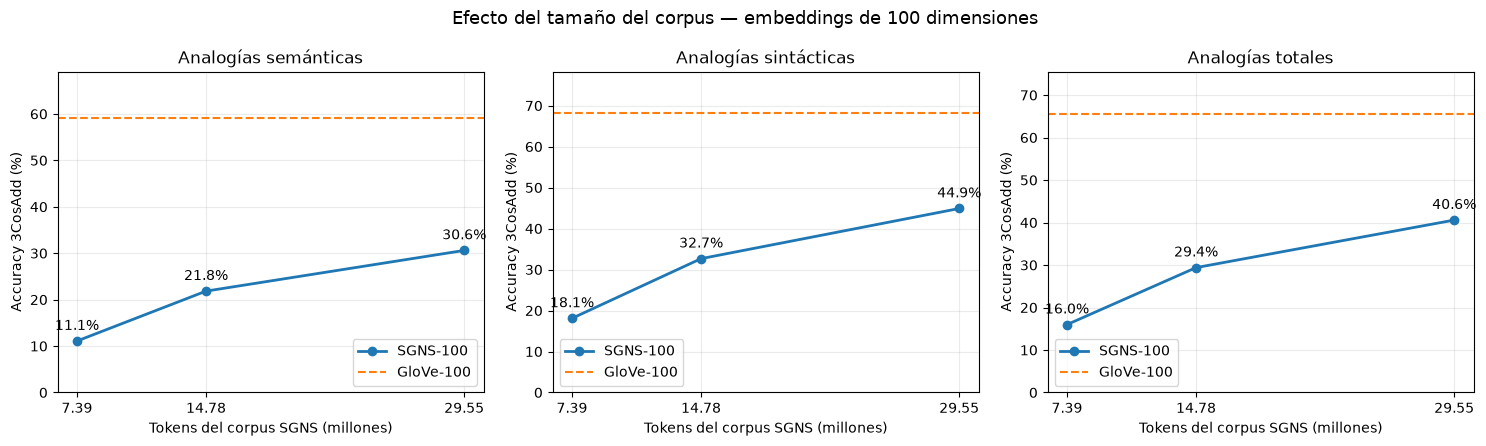

In [2]:
filas = []

for nombre, espacio in espacios_compartidos.items():
    print(f"Evaluando {nombre}...")

    resultado = EV.evaluate_analogies(
        espacio,
        preguntas,
        methods=("add",),
    )

    assert resultado["n_eval"] == n_evaluables

    filas.append({
        "modelo": nombre,
        "tokens": (
            historiales[nombre]["n_tokens"]
            if nombre in historiales else np.nan
        ),
        "accuracy_semanticas": resultado["add"]["semantic"],
        "accuracy_sintacticas": resultado["add"]["syntactic"],
        "accuracy_total": resultado["add"]["total"],
        "preguntas_evaluadas": resultado["n_eval"],
        "cobertura": resultado["coverage"],
    })

tabla_corpus = pd.DataFrame(filas).set_index("modelo")
tabla_corpus.to_csv(RESULTS / "analogias_vs_tokens.csv")

display(tabla_corpus)

sgns = tabla_corpus.loc[RUNS].sort_values("tokens")
glove = tabla_corpus.loc["GloVe-100"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metricas = [
    ("accuracy_semanticas", "Analogías semánticas"),
    ("accuracy_sintacticas", "Analogías sintácticas"),
    ("accuracy_total", "Analogías totales"),
]

x = sgns["tokens"].to_numpy() / 1_000_000

for ax, (columna, titulo) in zip(axes, metricas):
    y = sgns[columna].to_numpy() * 100

    ax.plot(x, y, "o-", linewidth=2, label="SGNS-100")
    ax.axhline(
        glove[columna] * 100,
        color="tab:orange",
        linestyle="--",
        label="GloVe-100",
    )

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.1f}%",
            (xi, yi),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
        )

    ax.set_title(titulo)
    ax.set_xlabel("Tokens del corpus SGNS (millones)")
    ax.set_ylabel("Accuracy 3CosAdd (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.2f}" for v in x])
    ax.set_ylim(0, min(100, max(y.max(), glove[columna] * 100) + 10))
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle(
    "Efecto del tamaño del corpus — embeddings de 100 dimensiones",
    fontsize=13,
)
plt.tight_layout()

plt.savefig(RESULTS / "analogias_vs_tokens.png", dpi=250)
plt.savefig(RESULTS / "analogias_vs_tokens.pdf")
plt.show()

### Análisis de resultados

Al aumentar el corpus, el accuracy total de SGNS aumentó de 15.98 % a 40.58 %. Las analogías sintácticas obtuvieron mayor accuracy que las semánticas en los tres tamaños de corpus.

La mejora fue de 13.41% al pasar del 25 % al 50 % del corpus, y de 11.19% al pasar del 50 % al 100 %.
Aunque incorporar más texto continuó siendo beneficioso, la segunda duplicación produjo una ganancia menor.

GloVe-100 alcanzó un accuracy total de 65.51 %, superando al SGNS entrenado con el corpus completo por 24.93%.
La diferencia fue mayor en las analogías semánticas que en las sintácticas.

Estos resultados muestran que el tamaño del corpus influye en el desempeño de SGNS, pero no permiten determinar qué proporción exacta de la diferencia con GloVe se debe al tamaño del corpus, al método de entrenamiento o a otras diferencias entre sus configuraciones y datos.

Todos los modelos se evaluaron sobre las mismas 11,833 preguntas, con una cobertura del 60.55 % y un vocabulario candidato compartido de 30,000 palabras.